# LLaMA 3.1-8B — Arabic Document Sensitivity Classifier
Fine-tuning LLaMA 3.1-8B with LoRA on Arabic documents, then evaluating on a held-out test set.
Classification follows **NDMO/SDAIA** sensitivity levels: عام · مقيد · سري · سري للغاية

## 0. Setup

In [ ]:
# Install all required libraries
!pip install -U trl transformers peft accelerate bitsandbytes datasets \
              scikit-learn pandas tqdm matplotlib arabic-reshaper python-bidi


In [ ]:
# Authenticate with Hugging Face (required to download LLaMA)
from huggingface_hub import login
from google.colab import userdata
login(token=userdata.get('HF_TOKEN'))


## 1. Fine-Tuning with LoRA
Trains a LoRA adapter on LLaMA 3.1-8B using 85% of the dataset (seed=42).

In [ ]:
# ── Imports ──────────────────────────────────────────────
import torch
import os
import pandas as pd
from google.colab import drive
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from trl import SFTTrainer, SFTConfig

# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking GPU...
Wed May 20 01:17:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   64C    P8             18W /   72W |       0MiB /  23034MiB |      0%      Defau


Example formatted sample:
أنت مساعد ذكي متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO.

صنّف الوثيقة التالية إلى فئة واحدة فقط من الفئات التالية:
عام، مقيد، سري، سري للغاية.

أجب باسم الفئة فقط دون أي شرح إضافي.

### الوثيقة:
ضمن أعمال التحسين المستمرة، تم رصد النقاط التالية ضمن التخطيط التشغيلي في الربع الحالي. أُدرجت الملاحظات ذات العلاقة في ملخص المرحلة بعد مقارنة النتائج. جرى تحقق تسلسل الإجراءات مع توثيق النتائج ضمن النطاق المعتمد. يرجى الاطلاع وإبداء الملاحظات عند الحاجة.

### التصنيف:
سري للغاية<|eot_id|>

Loading model...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Model loaded successfully.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Trainable parameters:
trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.



Starting LLaMA QLoRA fine-tuning...


In [ ]:
# ── Paths & Constants ────────────────────────────────────
BASE_MODEL_ID   = "meta-llama/Meta-Llama-3.1-8B-Instruct"
DATASET_PATH    = "/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv"
ADAPTER_SAVE    = "/content/drive/MyDrive/llama_ndmo_lora_adapters_v3/final_adapter"
VALID_CLASSES   = ["عام", "مقيد", "سري", "سري للغاية"]

# Load dataset and split: 85% train / 15% test (locked split)
df = pd.read_csv(DATASET_PATH)
dataset = Dataset.from_pandas(df)
split = dataset.train_test_split(test_size=0.15, seed=42)
train_dataset = split['train']

print(f"Training samples: {len(train_dataset)}")


Mounted at /content/drive
Total dataset size: 40000

Original class distribution:
sensitivity_level
سري للغاية    10000
سري           10000
مقيد          10000
عام           10000
Name: count, dtype: int64

Train: 28000
Validation: 6000
Test: 6000

Train distribution:
sensitivity_level
سري للغاية    7000
مقيد          7000
عام           7000
سري           7000
Name: count, dtype: int64

Validation distribution:
sensitivity_level
مقيد          1500
عام           1500
سري           1500
سري للغاية    1500
Name: count, dtype: int64

Test distribution:
sensitivity_level
مقيد          1500
عام           1500
سري           1500
سري للغاية    1500
Name: count, dtype: int64

Splits saved to: /content/drive/MyDrive/GP/llama_lora_splits



Example formatted sample:
أنت مساعد ذكي متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO.

صنّف الوثيقة التالية إلى فئة واحدة فقط من الفئات التالية:
عام، مقيد، سري، سري للغاية.

أجب باسم الفئة فقط دون أي شرح إضافي.

### الوثيقة:
ضمن أعمال التحسين المستمرة، تم رصد النقاط التالية ضمن التخطيط التشغيلي في الربع الحالي. أُدرجت الملاحظات ذات العلاقة في ملخص المرحلة بعد مقارنة النتائج. جرى تحقق تسلسل الإجراءات مع توثيق النتائج ضمن النطاق المعتمد. يرجى الاطلاع وإبداء الملاحظات عند الحاجة.

### التصنيف:
سري للغاية<|eot_id|>

Loading model...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Model loaded successfully.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Trainable parameters:
trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.



Checking for existing checkpoints...
Available checkpoints:
['checkpoint-500']

Latest checkpoint found: /content/drive/MyDrive/llama_ndmo_lora_adapters_v3/checkpoint-500

Resuming LLaMA QLoRA fine-tuning from latest checkpoint...



Training complete.

Final LoRA adapter saved to: /content/drive/MyDrive/llama_ndmo_lora_adapters_v3/final_adapter
Done. Adapter is ready for testing.


In [ ]:
# Format each row into a prompt+answer string for SFT
SYSTEM_PROMPT = "أنت مساعد ذكي متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO. صنف الوثيقة التالية إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية)."

def format_prompt(row):
    return {"formatted_text": f"System: {SYSTEM_PROMPT}\nUser: الوثيقة: {row['content']}\nAssistant: {row['sensitivity_level']}"}

train_dataset = train_dataset.map(format_prompt)
print("Sample prompt:")
print(train_dataset[0]['formatted_text'][:300])


Mounted at /content/drive
Total dataset size: 40000

Original class distribution:
sensitivity_level
سري للغاية    10000
سري           10000
مقيد          10000
عام           10000
Name: count, dtype: int64

Train: 28000
Validation: 6000
Test: 6000

Train distribution:
sensitivity_level
سري للغاية    7000
مقيد          7000
عام           7000
سري           7000
Name: count, dtype: int64

Validation distribution:
sensitivity_level
مقيد          1500
عام           1500
سري           1500
سري للغاية    1500
Name: count, dtype: int64

Test distribution:
sensitivity_level
مقيد          1500
عام           1500
سري           1500
سري للغاية    1500
Name: count, dtype: int64

Splits saved to: /content/drive/MyDrive/GP/llama_lora_splits



Example formatted sample:
أنت مساعد ذكي متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO.

صنّف الوثيقة التالية إلى فئة واحدة فقط من الفئات التالية:
عام، مقيد، سري، سري للغاية.

أجب باسم الفئة فقط دون أي شرح إضافي.

### الوثيقة:
ضمن أعمال التحسين المستمرة، تم رصد النقاط التالية ضمن التخطيط التشغيلي في الربع الحالي. أُدرجت الملاحظات ذات العلاقة في ملخص المرحلة بعد مقارنة النتائج. جرى تحقق تسلسل الإجراءات مع توثيق النتائج ضمن النطاق المعتمد. يرجى الاطلاع وإبداء الملاحظات عند الحاجة.

### التصنيف:
سري للغاية<|eot_id|>

Loading model...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Model loaded successfully.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Trainable parameters:
trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.



Checking for existing checkpoints...
Available checkpoints:
['checkpoint-500']

Latest checkpoint found: /content/drive/MyDrive/llama_ndmo_lora_adapters_v3/checkpoint-500

Resuming LLaMA QLoRA fine-tuning from latest checkpoint...



Training complete.

Final LoRA adapter saved to: /content/drive/MyDrive/llama_ndmo_lora_adapters_v3/final_adapter
Done. Adapter is ready for testing.


In [ ]:
# ── Load Base Model with 4-bit Quantization ─────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"  # Right padding is better for training

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
    torch_dtype=torch.float16
)
base_model.config.torch_dtype = torch.float16
base_model = prepare_model_for_kbit_training(base_model)

# Apply LoRA to attention and MLP projection layers
peft_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=["q_proj","v_proj","k_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)
model = get_peft_model(base_model, peft_config)

# Cast bfloat16 → float16 for consistency
for param in model.parameters():
    if param.dtype == torch.bfloat16:
        param.data = param.data.to(torch.float16)

print("Model ready for training.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking GPU...
Wed May 20 01:17:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   64C    P8             18W /   72W |       0MiB /  23034MiB |      0%      Defau


Example formatted sample:
أنت مساعد ذكي متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO.

صنّف الوثيقة التالية إلى فئة واحدة فقط من الفئات التالية:
عام، مقيد، سري، سري للغاية.

أجب باسم الفئة فقط دون أي شرح إضافي.

### الوثيقة:
ضمن أعمال التحسين المستمرة، تم رصد النقاط التالية ضمن التخطيط التشغيلي في الربع الحالي. أُدرجت الملاحظات ذات العلاقة في ملخص المرحلة بعد مقارنة النتائج. جرى تحقق تسلسل الإجراءات مع توثيق النتائج ضمن النطاق المعتمد. يرجى الاطلاع وإبداء الملاحظات عند الحاجة.

### التصنيف:
سري للغاية<|eot_id|>

Loading model...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Model loaded successfully.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Trainable parameters:
trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.



Starting LLaMA QLoRA fine-tuning...


In [ ]:
# ── Training Configuration & Launch ─────────────────────
sft_config = SFTConfig(
    output_dir=ADAPTER_SAVE,
    dataset_text_field="formatted_text",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,   # Effective batch size = 8
    optim="paged_adamw_32bit",
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    num_train_epochs=1,              # One full pass over training data
    save_strategy="epoch",
    logging_steps=50,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    fp16=False, bf16=False,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    processing_class=tokenizer,
    args=sft_config,
)

print("Starting fine-tuning...")
trainer.train()

# Save final LoRA adapter weights
trainer.model.save_pretrained(ADAPTER_SAVE)
print(f"Adapter saved at: {ADAPTER_SAVE}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking GPU...
Wed May 20 01:17:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   64C    P8             18W /   72W |       0MiB /  23034MiB |      0%      Defau


Example formatted sample:
أنت مساعد ذكي متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO.

صنّف الوثيقة التالية إلى فئة واحدة فقط من الفئات التالية:
عام، مقيد، سري، سري للغاية.

أجب باسم الفئة فقط دون أي شرح إضافي.

### الوثيقة:
ضمن أعمال التحسين المستمرة، تم رصد النقاط التالية ضمن التخطيط التشغيلي في الربع الحالي. أُدرجت الملاحظات ذات العلاقة في ملخص المرحلة بعد مقارنة النتائج. جرى تحقق تسلسل الإجراءات مع توثيق النتائج ضمن النطاق المعتمد. يرجى الاطلاع وإبداء الملاحظات عند الحاجة.

### التصنيف:
سري للغاية<|eot_id|>

Loading model...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Model loaded successfully.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Trainable parameters:
trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.



Starting LLaMA QLoRA fine-tuning...


## 2. Verify Saved Adapter

In [ ]:
# Check that the adapter files were saved correctly
if os.path.exists(ADAPTER_SAVE):
    files = os.listdir(ADAPTER_SAVE)
    print(f"Adapter files ({len(files)}):")
    for f in files:
        print(f"  {f}")
else:
    print("Adapter not found — check training completed successfully.")


Final adapter folder exists.
['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'chat_template.jinja', 'tokenizer_config.json', 'tokenizer.json']


## 3. Inference Setup
Load the fine-tuned model and prepare the test set.

In [ ]:
# Install inference dependencies (if not already installed)
!pip install -U transformers peft accelerate bitsandbytes datasets scikit-learn pandas tqdm matplotlib


In [ ]:
# ── Imports for Inference ────────────────────────────────
import os, re, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from google.colab import drive
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

drive.mount('/content/drive', force_remount=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Inference Paths ──────────────────────────────────────
BASE_MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"
ADAPTER_PATH  = "/content/drive/MyDrive/llama_ndmo_lora_adapters_v3/final_adapter"
DATASET_PATH  = "/content/drive/MyDrive/Project/synthetic_sensitivity_dataset_v3.csv"
test_path     = "/content/drive/MyDrive/Project/llama_splits/test_split.csv"
VALID_CLASSES = ["عام", "مقيد", "سري", "سري للغاية"]


Adapter exists: True
Test file exists: True
Output dir: /content/drive/MyDrive/llama_ndmo_lora_adapters_v3/evaluation_results


## 4. Load Test Data

In [ ]:
# Load the locked 15% test split
test_df = pd.read_csv(test_path)

# Validate required columns exist
for col in ["content", "sensitivity_level"]:
    assert col in test_df.columns, f"Missing column: {col}"

print(f"Test set: {len(test_df)} documents")
print(f"Class distribution:\n{test_df['sensitivity_level'].value_counts()}")


Test size: 6000

Test class distribution:
sensitivity_level
مقيد          1500
عام           1500
سري           1500
سري للغاية    1500
Name: count, dtype: int64


## 5. Load Fine-Tuned Model

In [ ]:
# ── Load Tokenizer & Merge LoRA Weights ─────────────────
# Left padding prevents hallucination during batch generation
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "left"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

# Merge fine-tuned LoRA weights onto base model
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()
print("Model loaded and ready for inference.")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Base model + LoRA adapter loaded successfully.


## 6. Run Inference

In [ ]:
# Prompt template used during both training and inference
SYSTEM_PROMPT = "أنت مساعد ذكي متخصص في تصنيف الوثائق الإدارية السعودية حسب معايير NDMO. صنف الوثيقة التالية إلى فئة واحدة فقط: (عام، مقيد، سري، سري للغاية)."

def build_prompt(text):
    return f"System: {SYSTEM_PROMPT}\nUser: الوثيقة: {text}\nAssistant: "

def clean_prediction(raw):
    """Extract a valid sensitivity label from raw model output."""
    if not isinstance(raw, str):
        return "غير معروف"
    for cls in ["سري للغاية", "سري", "مقيد", "عام"]:
        if cls in raw:
            return cls
    return "غير معروف"


In [ ]:
# ── Quick Sanity Check on 10 Samples ────────────────────
sample_df = test_df.sample(10, random_state=42).reset_index(drop=True)

for i, row in sample_df.iterrows():
    prompt = build_prompt(row['content'])
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to("cuda")
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=10,
                                do_sample=False, pad_token_id=tokenizer.eos_token_id)
    raw = tokenizer.decode(output[0], skip_special_tokens=True).split("Assistant:")[-1].strip()
    pred = clean_prediction(raw)
    status = "✓" if pred == row['sensitivity_level'] else "✗"
    print(f"{status} True: {row['sensitivity_level']:<12} Pred: {pred}")


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


True label: عام
Raw output: ' سري'
Predicted: سري
True label: عام
Raw output: ' عام'
Predicted: عام
True label: سري
Raw output: ' سري'
Predicted: سري
True label: عام
Raw output: ' عام'
Predicted: عام
True label: عام
Raw output: ' عام'
Predicted: عام
True label: سري
Raw output: 'سري'
Predicted: سري
True label: عام
Raw output: ' عام'
Predicted: عام
True label: سري
Raw output: ' سري'
Predicted: سري
True label: سري
Raw output: ' سري'
Predicted: سري
True label: مقيد
Raw output: ' سري'
Predicted: سري


In [ ]:
# ── Full Test Set Batch Inference ────────────────────────
def predict_batch(texts, batch_size=4):
    """Classify all documents in batches, returns (predictions, raw_outputs)."""
    predictions, raw_outputs = [], []

    for start in tqdm(range(0, len(texts), batch_size), desc="Classifying"):
        batch   = texts[start : start + batch_size]
        prompts = [build_prompt(t) for t in batch]
        inputs  = tokenizer(prompts, return_tensors="pt", padding=True,
                            truncation=True, max_length=512).to("cuda")

        with torch.no_grad():
            outputs = model.generate(
                **inputs, max_new_tokens=10,
                do_sample=False, pad_token_id=tokenizer.eos_token_id
            )

        for out in tokenizer.batch_decode(outputs, skip_special_tokens=True):
            raw  = out.split("Assistant:")[-1].strip()
            pred = clean_prediction(raw)
            predictions.append(pred)
            raw_outputs.append(raw)

    return predictions, raw_outputs


texts       = test_df['content'].tolist()
true_labels = test_df['sensitivity_level'].tolist()
predictions, raw_outputs = predict_batch(texts)

print(f"Done. Total predictions: {len(predictions)}")


Prediction completed.
  sensitivity_level predicted_label raw_model_output
0              مقيد            مقيد             مقيد
1              مقيد            مقيد             مقيد
2               عام             عام              عام
3               عام             عام              عام
4               سري             سري              سري


## 7. Evaluation

In [ ]:
# Install Arabic text rendering libraries
!pip install -q arabic-reshaper python-bidi

from sklearn.metrics import accuracy_score, f1_score, classification_report
import arabic_reshaper
from bidi.algorithm import get_display

display_labels = ["Public", "Restricted", "Secret", "Top Secret"]

acc      = accuracy_score(true_labels, predictions)
macro_f1 = f1_score(true_labels, predictions, average="macro", labels=VALID_CLASSES)

print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")
print("\nClassification Report:")
print(classification_report(true_labels, predictions,
                             labels=VALID_CLASSES, target_names=display_labels, digits=4))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 25.6 MB/s eta 0:00:00
Accuracy: 0.7175
Macro F1: 0.7262


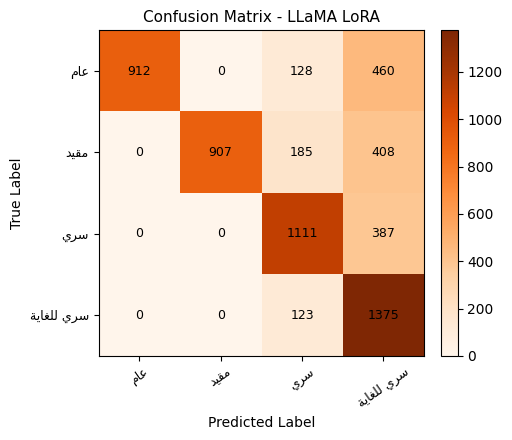

Confusion matrix saved to: /content/drive/MyDrive/llama_ndmo_lora_adapters_v3/evaluation_results/confusion_matrix_llama_lora_orange.png


In [ ]:
# ── Confusion Matrix ────────────────────────────────────
from sklearn.metrics import confusion_matrix

def fix_arabic(text):
    """Reshape and apply BiDi for correct Arabic rendering in matplotlib."""
    return get_display(arabic_reshaper.reshape(str(text)))

cm = confusion_matrix(true_labels, predictions, labels=VALID_CLASSES)
fixed_labels = [fix_arabic(l) for l in VALID_CLASSES]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(fixed_labels))); ax.set_xticklabels(fixed_labels, fontsize=11)
ax.set_yticks(range(len(fixed_labels))); ax.set_yticklabels(fixed_labels, fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max()/2 else "black")

ax.set_title("LLaMA Fine-Tuned — Confusion Matrix", fontsize=13)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.show()
